# F_S3.2 — Complex Path: SiZer vs KL/QR/HD Comparison

Compare two methods for classifying shapes that the Simple (power-law) path cannot resolve:
- **Method A**: SiZer (multi-scale derivative analysis)
- **Method B**: KL / QR / HD (distributional tests from the thresholds paper)

Input: cases from Gate 2 Complex + Simple path R² fail ("Enter next branch").

## Shared setup

Reuse config, catalogue, data loading, Gate 1, Gate 2 from F_S3.

In [32]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

def count_percent(count, total):
    count = int(count)
    total = int(total)
    return f'{count:,} ({count / total:.1%})' if total else f'{count:,} (N/A)'

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate repo root.')

REPO_ROOT = locate_repo_root()

# ═══════════════════════════════════════════════════════
# ██  DATA SOURCE SWITCH  ██
# ═══════════════════════════════════════════════════════
DATA_SOURCE = 'E'    # E data (S3_snr_mic_sweep)
# DATA_SOURCE = 'F'      # F data (S1_parameterized)

# ── E data: variant_level filter ──
# Available: 'mild', 'none', 'standard', 'strong'
# E_VARIANT_FILTER = ['strong','standard']
E_VARIANT_FILTER = ['strong']

# ── F data: strength_name filter ──
# Available: 'very_weak', 'weak', 'medium', 'strong', 'very_strong'
F_STRENGTH_FILTER = ['strong']
# ═══════════════════════════════════════════════════════

if DATA_SOURCE == 'E':
    INPUT_DIR = REPO_ROOT / 'E' / 'output' / 'S3_snr_mic_sweep'
    CASES_FILE = 'cases.csv'
    SCATTER_FILE = 'scatter_points.npz'
    METRICS_DIR = INPUT_DIR
elif DATA_SOURCE == 'F':
    INPUT_DIR = REPO_ROOT / 'F' / 'output' / 'S1_parameterized'
    CASES_FILE = 'representative_cases.csv'
    SCATTER_FILE = 'representative_scatter_points.npz'
    METRICS_DIR = REPO_ROOT / 'F' / 'output' / 'S2_metrics'

OUT_DIR = REPO_ROOT / 'F' / 'output' / 'S3_shape_classification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_SOURCE = {DATA_SOURCE!r}')
print(f'Input:  {INPUT_DIR.relative_to(REPO_ROOT)}')
if DATA_SOURCE == 'F':
    print(f'Metrics: {METRICS_DIR.relative_to(REPO_ROOT)}')

DATA_SOURCE = 'E'
Input:  E/output/S3_snr_mic_sweep


In [33]:
# Family catalogue: ground-truth properties for each signal family.
# F17 (Quadratic peak) was removed in F; F18 is standalone.
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear positive',           'direction': 'positive',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F02': {'name': 'Linear negative',           'direction': 'negative',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F03': {'name': 'Power convex positive',     'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F04': {'name': 'Power convex negative',     'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F05': {'name': 'Power concave positive',    'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F06': {'name': 'Power concave negative',    'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F07': {'name': 'Saturation positive',       'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'saturation',            'tp': 0},
    'F08': {'name': 'Saturation negative',       'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'saturation',            'tp': 0},
    'F09': {'name': 'Log positive',              'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F10': {'name': 'Log negative',              'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F11': {'name': 'Exponential positive',      'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F12': {'name': 'Exponential negative',      'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F13': {'name': 'S-curve positive',          'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F14': {'name': 'S-curve negative',          'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F15': {'name': 'Threshold positive',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F16': {'name': 'Threshold negative',        'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F18': {'name': 'Quadratic valley (U)',       'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'valley',                'tp': 1},
    'F19': {'name': 'Spike',                     'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'spike',                 'tp': 1},
    'F20': {'name': 'Inverted Spike',            'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'inverted spike',        'tp': 1},
    'F21': {'name': 'Cubic',                     'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'cubic',                 'tp': 2},
    'F22': {'name': 'Oscillation',               'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'oscillation',           'tp': 'multiple'},
    'F23': {'name': 'Two Lines',                 'direction': 'positive',     'linearity': 'multi-branch linear', 'monotonicity': 'multi-branch',  'curvature': 'N/A',    'special_shape': 'two lines',             'tp': 0},
    'F24': {'name': 'Line and Parabola',         'direction': 'none/local',   'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'mixed',  'special_shape': 'line + parabola',       'tp': 1},
    'F25': {'name': 'Multi-regime threshold',    'direction': 'positive',     'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'convex', 'special_shape': 'overlapping J',         'tp': 'multiple'},
    'F26': {'name': 'Windowed threshold',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'windowed J',            'tp': 'multiple'},
    'Null': {'name': 'No relationship',          'direction': 'N/A',          'linearity': 'N/A',                 'monotonicity': 'N/A',           'curvature': 'N/A',    'special_shape': 'none',                  'tp': 'N/A'},
}

# Build the expected shape_label mapping from the catalogue.
# This is the ground-truth: what shape should the classifier assign at high SNR?
EXPECTED_SHAPE = {}
for fid, props in FAMILY_CATALOGUE.items():
    if fid == 'Null':
        EXPECTED_SHAPE[fid] = 'no_global'
        continue
    d = props['direction']
    mono = props['monotonicity']
    lin = props['linearity']
    curv = props['curvature']
    shape = props['special_shape']
    tp = props['tp']

    # Simple monotonic families → gate2 = Simple
    if mono == 'monotonic':
        if lin == 'linear':
            EXPECTED_SHAPE[fid] = f'{d}_line'
        elif shape == 'S-curve':
            EXPECTED_SHAPE[fid] = f'{d}_s_shaped'
        elif shape == 'threshold':
            EXPECTED_SHAPE[fid] = f'{d}_threshold'
        elif curv == 'concave':
            EXPECTED_SHAPE[fid] = f'{d}_concave'
        elif curv == 'convex':
            EXPECTED_SHAPE[fid] = f'{d}_convex'
        else:
            EXPECTED_SHAPE[fid] = 'simple_other'
    # Non-monotonic / multi-branch → gate2 = Complex
    elif mono == 'non-monotonic':
        if tp == 1:
            EXPECTED_SHAPE[fid] = 'u_inv_u_spike'
        elif tp == 2:
            EXPECTED_SHAPE[fid] = 'complex_cubic'
        elif tp == 'multiple' and 'oscillat' in shape:
            EXPECTED_SHAPE[fid] = 'oscillatory'
        elif tp == 'multiple' and 'windowed' in shape:
            EXPECTED_SHAPE[fid] = 'multi_step_threshold'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'
    elif mono == 'multi-branch':
        if 'two lines' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'parabola' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'overlapping' in shape or 'J' in shape:
            EXPECTED_SHAPE[fid] = 'n_way_branching'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'

catalogue_df = pd.DataFrame.from_dict(FAMILY_CATALOGUE, orient='index').reset_index(names='family_id')
catalogue_df['expected_shape'] = catalogue_df['family_id'].map(EXPECTED_SHAPE)
print(f'{len(FAMILY_CATALOGUE)} families loaded')
display(catalogue_df[['family_id', 'name', 'monotonicity', 'curvature', 'special_shape', 'expected_shape']])

26 families loaded


,family_id,name,monotonicity,curvature,special_shape,expected_shape
0,F01,Linear positive,monotonic,N/A,none,positive_line
1,F02,Linear negative,monotonic,N/A,none,negative_line
2,F03,Power convex positive,monotonic,convex,none,positive_convex
3,F04,Power convex negative,monotonic,concave,none,negative_concave
4,F05,Power concave positive,monotonic,concave,none,positive_concave
5,F06,Power concave negative,monotonic,convex,none,negative_convex
6,F07,Saturation positive,monotonic,concave,saturation,positive_concave
7,F08,Saturation negative,monotonic,convex,saturation,negative_convex
8,F09,Log positive,monotonic,concave,none,positive_concave
9,F10,Log negative,monotonic,convex,none,negative_convex


In [34]:
cases_df = pd.read_csv(INPUT_DIR / CASES_FILE, low_memory=False)
metrics_df = pd.read_parquet(METRICS_DIR / 'metrics_full.parquet')
pts = np.load(INPUT_DIR / SCATTER_FILE)
x_all = pts['x']
y_all = pts['y']
del pts

if DATA_SOURCE == 'E':
    cases_df['_pt_idx'] = pd.to_numeric(cases_df['candidate_index'], errors='raise').astype(np.int64)
else:
    cases_df['_pt_idx'] = np.arange(len(cases_df), dtype=np.int64)

if len(x_all) != len(cases_df) or len(y_all) != len(cases_df):
    raise ValueError(f'Scatter arrays ({len(x_all)}) and cases ({len(cases_df)}) row count mismatch.')
if cases_df['case_id'].duplicated().any() or metrics_df['case_id'].duplicated().any():
    raise ValueError('case_id must be unique in both cases and metrics.')

# ── Apply strength filter (uses config switch) ──
if DATA_SOURCE == 'E':
    _filter_col = 'variant_level'
    _filter_vals = E_VARIANT_FILTER
else:
    _filter_col = 'strength_name'
    _filter_vals = F_STRENGTH_FILTER

if _filter_vals is not None:
    levels = [_filter_vals] if isinstance(_filter_vals, str) else list(_filter_vals)
    _before = len(cases_df)
    cases_df = cases_df[cases_df[_filter_col].isin(levels)].reset_index(drop=True)
    print(f'{_filter_col} filter: {levels} → kept {len(cases_df):,} / {_before:,} cases')
else:
    print(f'{_filter_col} filter: OFF (all levels)')

data = cases_df.merge(metrics_df, on='case_id', how='inner', validate='one_to_one')
data = data.reset_index(drop=True)
data['is_null'] = data['family_id'].eq('Null')
data['_pt_idx'] = pd.to_numeric(data['_pt_idx'], errors='raise').astype(np.int64)
if not data['_pt_idx'].between(0, len(x_all) - 1).all():
    raise IndexError('A mapped scatter-point index is outside the stored arrays.')
if data['_pt_idx'].duplicated().any():
    raise ValueError('Multiple classified cases map to the same scatter-point row.')

print(f'Loaded {len(data):,} cases × {x_all.shape[1]} points  [DATA_SOURCE={DATA_SOURCE}]')
print(f'  Signal: {(~data["is_null"]).sum():,}   Null: {data["is_null"].sum():,}')
print(f'  Families: {sorted(data["family_id"].unique())}')

variant_level filter: ['strong'] → kept 31,780 / 95,440 cases
Loaded 31,780 cases × 500 points  [DATA_SOURCE=E]
  Signal: 31,780   Null: 0
  Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [35]:
# ── Gate 1 thresholds ──
MIC_STRONG = 0.8
MIC_INTERMEDIATE = 0.6

def assign_gate1(mic):
    if mic >= MIC_STRONG:
        return 'strong_global'
    elif mic >= MIC_INTERMEDIATE:
        return 'intermediate_global'
    else:
        return 'no_global'

data['gate1'] = data['MIC'].apply(assign_gate1)

_g1_counts = data.groupby(['family_id', 'gate1']).size().unstack(fill_value=0)
_g1_counts = _g1_counts.reindex(
    columns=['strong_global', 'intermediate_global', 'no_global'], fill_value=0
).sort_index()
_g1_totals = _g1_counts.sum(axis=1)
_g1 = pd.DataFrame(index=_g1_counts.index)
_g1['family_name'] = _g1.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g1['Total'] = [count_percent(n, n) for n in _g1_totals]
for col in _g1_counts.columns:
    _g1[col] = [count_percent(n, total) for n, total in zip(_g1_counts[col], _g1_totals)]
print(f'=== Gate 1: MIC >= {MIC_STRONG} → strong, >= {MIC_INTERMEDIATE} → intermediate ===')
display(_g1)
print(f'\nOverall: {count_percent((data["gate1"]=="strong_global").sum(), len(data))} strong / '
      f'{count_percent((data["gate1"]=="intermediate_global").sum(), len(data))} intermediate / '
      f'{count_percent((data["gate1"]=="no_global").sum(), len(data))} no_global')

=== Gate 1: MIC >= 0.8 → strong, >= 0.6 → intermediate ===


,family_name,Total,strong_global,intermediate_global,no_global
family_id,,,,,
F01,Linear positive,"2,270 (100.0%)",994 (43.8%),155 (6.8%),"1,121 (49.4%)"
F03,Power convex positive,"2,270 (100.0%)",806 (35.5%),235 (10.4%),"1,229 (54.1%)"
F05,Power concave positive,"2,270 (100.0%)",856 (37.7%),176 (7.8%),"1,238 (54.5%)"
F07,Saturation positive,"2,270 (100.0%)",55 (2.4%),582 (25.6%),"1,633 (71.9%)"
F13,S-curve positive,"2,270 (100.0%)","1,091 (48.1%)",114 (5.0%),"1,065 (46.9%)"
F15,Threshold positive,"2,270 (100.0%)","1,112 (49.0%)",99 (4.4%),"1,059 (46.7%)"
F18,Quadratic valley (U),"2,270 (100.0%)",916 (40.4%),173 (7.6%),"1,181 (52.0%)"
F19,Spike,"2,270 (100.0%)",0 (0.0%),0 (0.0%),"2,270 (100.0%)"
F21,Cubic,"2,270 (100.0%)",549 (24.2%),332 (14.6%),"1,389 (61.2%)"



Overall: 7,457 (23.5%) strong / 2,667 (8.4%) intermediate / 21,656 (68.1%) no_global


In [36]:
# ── Gate 2 thresholds ──
PEARSON_THRESHOLD = 0.7
USE_SPEARMAN_GATE = False
SPEARMAN_THRESHOLD = 0.7

# ── MIC range selector ──
# MIC_ANALYSIS_GATE = 'strong_global'          # MIC >= 0.8
MIC_ANALYSIS_GATE = 'intermediate_global'      # 0.6 <= MIC < 0.8

mask_analysis = data['gate1'] == MIC_ANALYSIS_GATE
data['gate2'] = None

pearson_ok = data.loc[mask_analysis, 'pearson_r'].abs() >= PEARSON_THRESHOLD
if USE_SPEARMAN_GATE:
    spearman_ok = data.loc[mask_analysis, 'spearman_rho'].abs() >= SPEARMAN_THRESHOLD
    simple_mask = pearson_ok & spearman_ok
    gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} AND |Spearman| >= {SPEARMAN_THRESHOLD}'
else:
    simple_mask = pearson_ok
    gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} (Spearman gate OFF)'

data.loc[mask_analysis, 'gate2'] = np.where(simple_mask, 'Simple', 'Complex')

_g2_data = data.loc[mask_analysis]
_g2_counts = _g2_data.groupby(['family_id', 'gate2']).size().unstack(fill_value=0)
_g2_counts = _g2_counts.reindex(columns=['Simple', 'Complex'], fill_value=0).sort_index()
_g2_totals = _g2_counts.sum(axis=1)
_g2 = pd.DataFrame(index=_g2_counts.index)
_g2['family_name'] = _g2.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g2['Total'] = [count_percent(n, n) for n in _g2_totals]
for col in _g2_counts.columns:
    _g2[col] = [count_percent(n, total) for n, total in zip(_g2_counts[col], _g2_totals)]
print(f'=== Gate 2 [{MIC_ANALYSIS_GATE}]: {gate2_desc} ===')
display(_g2)
print(f'\nOverall: {count_percent(_g2_data["gate2"].eq("Simple").sum(), len(_g2_data))} Simple / '
      f'{count_percent(_g2_data["gate2"].eq("Complex").sum(), len(_g2_data))} Complex '
      f'out of {len(_g2_data):,} {MIC_ANALYSIS_GATE}')

=== Gate 2 [intermediate_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,155 (100.0%),155 (100.0%),0 (0.0%)
F03,Power convex positive,235 (100.0%),235 (100.0%),0 (0.0%)
F05,Power concave positive,176 (100.0%),176 (100.0%),0 (0.0%)
F07,Saturation positive,582 (100.0%),0 (0.0%),582 (100.0%)
F13,S-curve positive,114 (100.0%),103 (90.4%),11 (9.6%)
F15,Threshold positive,99 (100.0%),32 (32.3%),67 (67.7%)
F18,Quadratic valley (U),173 (100.0%),0 (0.0%),173 (100.0%)
F21,Cubic,332 (100.0%),332 (100.0%),0 (0.0%)
F22,Oscillation,153 (100.0%),0 (0.0%),153 (100.0%)



Overall: 1,033 (38.7%) Simple / 1,634 (61.3%) Complex out of 2,667 intermediate_global


## Run Simple path (power-law only)

Rerun the power-law classification to identify which cases enter the Complex path:
- Gate 2 Complex (|Pearson| < 0.7)
- Simple path R² fail (power-law R² < threshold → "Enter next branch")

In [37]:
# ── Simple path thresholds ──
R2_POWER_THRESHOLD = 0.85
LINEAR_B_TOLERANCE = 0.05

# ── Classification order switch ──
# 'r2_first'     : (default) check R² >= threshold, then check |b-1| for linear
# 'linear_first' : check |b-1| <= tolerance first to extract linear, then R² for concave/convex
CLASSIFICATION_ORDER = 'r2_first'   # switch: 'r2_first' or 'linear_first'

def _power_law(x, a, b, c):
    return a * np.power(np.maximum(x, 1e-10), b) + c


def _fit_power_law(x, y):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 1e-6)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    slope = np.polyfit(x, y, 1)[0]
    a0 = slope
    for b0 in [1.0, 0.5, 2.0, 0.3, 3.0]:
        try:
            popt, _ = curve_fit(
                _power_law, x, y, p0=[a0, b0, np.median(y)],
                maxfev=5000,
                bounds=([-np.inf, 0.05, -np.inf], [np.inf, 8.0, np.inf]),
            )
            y_pred = _power_law(x, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 >= 0:
                return (*popt, r2)
        except (RuntimeError, ValueError):
            continue
    return None


def classify_power_law_stage(x, y):
    """Return a terminal power-law label, or None for cubic fallthrough.

    Two modes controlled by CLASSIFICATION_ORDER:
      'r2_first'     – R² gate first, then |b-1| for linear  (default)
      'linear_first' – |b-1| gate first for linear, then R² for concave/convex
    """
    pw = _fit_power_law(x, y)
    if pw is None:
        return None

    a, b, c, r2 = pw
    ab = a * b
    direction = 'positive' if ab > 0 else 'negative'
    details = {'step': 'power_law', 'a': a, 'b': b, 'c': c, 'r2': r2}

    if CLASSIFICATION_ORDER == 'linear_first':
        # Mode B: check |b-1| first → linear; then R² for concave/convex
        if abs(b - 1) <= LINEAR_B_TOLERANCE:
            return f'{direction}_line', details
        if r2 >= R2_POWER_THRESHOLD:
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None
    else:
        # Mode A (default): R² gate first, then classify
        if r2 >= R2_POWER_THRESHOLD:
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return f'{direction}_line', details
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None

print(f'Power-law stage helpers defined.  CLASSIFICATION_ORDER = {CLASSIFICATION_ORDER!r}')

Power-law stage helpers defined.  CLASSIFICATION_ORDER = 'r2_first'


In [38]:
import time

pt_idx = data['_pt_idx'].values
mask_simple = (data['gate2'] == 'Simple').values
mask_complex_g2 = (data['gate2'] == 'Complex').values
idx_simple = np.where(mask_simple)[0]

pw_labels = np.full(len(data), '', dtype=object)
pw_r2_all = np.full(len(data), np.nan)
pw_a_all = np.full(len(data), np.nan)
pw_b_all = np.full(len(data), np.nan)

t0 = time.time()
for i in tqdm(idx_simple, desc='Power-law stage'):
    pi = pt_idx[i]
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    pw = _fit_power_law(x, y)
    if pw is not None:
        a, b, c, r2 = pw
        pw_r2_all[i] = r2
        pw_a_all[i] = a
        pw_b_all[i] = b
        result = classify_power_law_stage(x, y)
        if result is not None:
            pw_labels[i] = result[0]
            continue
    pw_labels[i] = 'r2_fail'
print(f'Power-law: {len(idx_simple):,} cases in {time.time()-t0:.1f}s')

data['pw_label'] = pw_labels
data['pw_r2'] = pw_r2_all

# Collect Complex-path cases
mask_r2_fail = (data['pw_label'] == 'r2_fail') & mask_simple
mask_enter_complex = mask_complex_g2 | mask_r2_fail
data['enters_complex'] = mask_enter_complex

complex_data = data[mask_enter_complex].copy()
print(f'\nComplex path entry: {len(complex_data):,} cases')
print(f'  from Gate 2 Complex: {mask_complex_g2.sum():,}')
print(f'  from Simple R² fail: {mask_r2_fail.sum():,}')
print(f'\nFamily breakdown:')
_fc = complex_data.groupby(['family_id']).size().reset_index(name='n')
_fc['family_name'] = _fc['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
display(_fc.set_index('family_id'))

Power-law stage: 100%|██████████| 1033/1033 [00:04<00:00, 250.94it/s]

Power-law: 1,033 cases in 4.1s

Complex path entry: 2,411 cases
  from Gate 2 Complex: 1,634
  from Simple R² fail: 777

Family breakdown:


,n,family_name
family_id,,
F01,155,Linear positive
F03,78,Power convex positive
F05,77,Power concave positive
F07,582,Saturation positive
F13,114,S-curve positive
F15,99,Threshold positive
F18,173,Quadratic valley (U)
F21,332,Cubic
F22,153,Oscillation


## Method A — Local-linear derivative with multiscale turning-point consensus

At each bandwidth, compute the local-linear derivative β₁(x, h) directly (no SE, no significance test).
Count stable turning points (sign changes of β₁) across multiple bandwidths.

- **Bandwidth range**: geomspace(0.04, 0.18, 5) on x ∈ [0, 1]
- **Interior only**: x ∈ [0.05, 0.95] to avoid boundary bias
- **Short-segment filter**: sign runs < 5% of grid are ignored (noise)
- **P_2TP**: fraction of bandwidths with exactly 2 TPs
- **TP stability**: check TP positions are consistent across bandwidths

In [39]:
# ── Local-linear derivative with multiscale TP consensus ──

FLAT_FRAC = 0.05  # |β₁| < 5% of max|β₁| → treated as flat (zero)

def multiscale_tp_analysis(x, y, n_bandwidths=5, n_grid=200,
                           h_min=0.04, h_max=0.18,
                           interior=(0.05, 0.95),
                           min_run_frac=0.05,
                           flat_frac=FLAT_FRAC):
    """Compute local-linear derivative at multiple bandwidths, count turning points.
    
    No significance test — uses multiscale consensus as regularization.
    """
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    n = len(x)
    if n < 20:
        return None
    
    # Normalize x to [0, 1]
    x_min, x_max = x.min(), x.max()
    x_range = x_max - x_min
    if x_range < 1e-10:
        return None
    x_norm = (x - x_min) / x_range
    
    x_grid = np.linspace(0, 1, n_grid)
    bandwidths = np.geomspace(h_min, h_max, n_bandwidths)
    
    # Interior mask
    interior_mask = (x_grid >= interior[0]) & (x_grid <= interior[1])
    min_run_len = max(int(min_run_frac * interior_mask.sum()), 3)
    
    per_bw = []
    deriv_matrix = np.zeros((n_bandwidths, n_grid))
    
    for bw_idx, h in enumerate(bandwidths):
        beta1_row = np.full(n_grid, np.nan)
        
        for gi, xg in enumerate(x_grid):
            w = np.exp(-0.5 * ((x_norm - xg) / h) ** 2)
            w_sum = w.sum()
            if w_sum < 1e-10:
                continue
            
            dx = x_norm - xg
            s0 = w_sum
            s1 = (w * dx).sum()
            s2 = (w * dx ** 2).sum()
            denom = s0 * s2 - s1 ** 2
            if abs(denom) < 1e-20:
                continue
            
            beta1 = (s0 * (w * dx * y).sum() - s1 * (w * y).sum()) / denom
            beta1_row[gi] = beta1
        
        deriv_matrix[bw_idx] = beta1_row
        
        # ── Count TPs in interior, filtering short runs + flat regions ──
        interior_deriv = beta1_row[interior_mask]
        eps = flat_frac * np.nanmax(np.abs(interior_deriv)) if np.any(np.isfinite(interior_deriv)) else 0.0
        tp_count, tp_positions = _count_stable_tps(
            interior_deriv, x_grid[interior_mask], min_run_len, eps
        )
        
        per_bw.append({
            'bw_index': bw_idx + 1,
            'bandwidth': float(h),
            'tp_count': int(tp_count),
            'tp_positions': tp_positions,
        })
    
    # ── P_2TP ──
    n_2tp = sum(1 for bw in per_bw if bw['tp_count'] == 2)
    p_2tp = n_2tp / n_bandwidths
    
    # ── TP position stability ──
    tp_stable = _check_tp_stability(per_bw)
    
    return {
        'per_bw': per_bw,
        'p_2tp': p_2tp,
        'n_2tp_bw': n_2tp,
        'n_bandwidths': n_bandwidths,
        'tp_stable': tp_stable,
        'deriv_matrix': deriv_matrix,
        'x_grid': x_grid,
    }


def _count_stable_tps(deriv, x_positions, min_run_len, eps=0.0):
    """Count turning points from stable sign runs in the derivative.
    
    Points with |deriv| < eps are treated as flat (ignored like NaN).
    """
    n = len(deriv)
    if n < 2:
        return 0, []
    
    runs = []  # list of (sign, start_idx, end_idx)
    current_sign = 0
    current_start = 0
    
    for i in range(n):
        if np.isnan(deriv[i]) or abs(deriv[i]) < eps:
            if current_sign != 0 and (i - current_start) >= min_run_len:
                runs.append((current_sign, current_start, i - 1))
            current_sign = 0
            continue
        
        s = 1 if deriv[i] > 0 else -1
        if s != current_sign:
            if current_sign != 0 and (i - current_start) >= min_run_len:
                runs.append((current_sign, current_start, i - 1))
            current_sign = s
            current_start = i
    
    # Last run
    if current_sign != 0 and (n - current_start) >= min_run_len:
        runs.append((current_sign, current_start, n - 1))
    
    # Count transitions between runs of different sign
    tp_count = 0
    tp_positions = []
    for i in range(1, len(runs)):
        if runs[i][0] != runs[i - 1][0]:
            tp_count += 1
            idx_mid = (runs[i - 1][2] + runs[i][1]) // 2
            if idx_mid < len(x_positions):
                tp_positions.append(float(x_positions[idx_mid]))
    
    return tp_count, tp_positions


def _check_tp_stability(per_bw):
    """Check if TP positions are stable across bandwidths that have 2 TPs."""
    bws_with_2tp = [bw for bw in per_bw if bw['tp_count'] == 2]
    if len(bws_with_2tp) < 2:
        return len(bws_with_2tp) == 1
    
    tp1_positions = [bw['tp_positions'][0] for bw in bws_with_2tp]
    tp2_positions = [bw['tp_positions'][1] for bw in bws_with_2tp]
    
    tp1_range = max(tp1_positions) - min(tp1_positions)
    tp2_range = max(tp2_positions) - min(tp2_positions)
    
    return tp1_range < 0.15 and tp2_range < 0.15

print(f'Multiscale TP helpers defined.  FLAT_FRAC = {FLAT_FRAC}')
print(f'Bandwidths: {np.geomspace(0.04, 0.18, 5).round(4)}')

Multiscale TP helpers defined.  FLAT_FRAC = 0.05
Bandwidths: [0.04   0.0583 0.0849 0.1236 0.18  ]


In [40]:
# ── Run multiscale TP analysis on all Complex-path cases ──
sizer_results = []
sizer_per_bw_records = []

t0 = time.time()
for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc='Multiscale TP'):
    pi = int(row['_pt_idx'])
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    result = multiscale_tp_analysis(x, y)
    
    cid = row['case_id']
    fid = row['family_id']
    
    if result is not None:
        tp_counts = [bw['tp_count'] for bw in result['per_bw']]
        n_bw = result['n_bandwidths']
        sizer_results.append({
            'case_id': cid, 'family_id': fid,
            'n_0tp_bw': sum(1 for t in tp_counts if t == 0),
            'n_1tp_bw': sum(1 for t in tp_counts if t == 1),
            'n_2tp_bw': sum(1 for t in tp_counts if t == 2),
            'n_3tp_bw': sum(1 for t in tp_counts if t == 3),
            'n_gt3tp_bw': sum(1 for t in tp_counts if t > 3),
            'tp_stable': result['tp_stable'],
        })
        for bw_info in result['per_bw']:
            sizer_per_bw_records.append({
                'case_id': cid, 'family_id': fid,
                'bw_index': bw_info['bw_index'],
                'bandwidth': bw_info['bandwidth'],
                'tp_count': bw_info['tp_count'],
                'tp_positions': bw_info['tp_positions'],
            })
    else:
        sizer_results.append({
            'case_id': cid, 'family_id': fid,
            'n_0tp_bw': 0, 'n_1tp_bw': 0, 'n_2tp_bw': 0,
            'n_3tp_bw': 0, 'n_gt3tp_bw': 0, 'tp_stable': False,
        })

print(f'Multiscale TP: {len(sizer_results):,} cases in {time.time()-t0:.1f}s')

sizer_df = pd.DataFrame(sizer_results)
sizer_df['family_name'] = sizer_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
sizer_bw_df = pd.DataFrame(sizer_per_bw_records)

print(f'\nSummary per family (mean # bandwidths supporting each TP count):')
display(sizer_df.groupby(['family_id', 'family_name']).agg(
    n=('case_id', 'size'),
    tp0=('n_0tp_bw', 'mean'),
    tp1=('n_1tp_bw', 'mean'),
    tp2=('n_2tp_bw', 'mean'),
    tp3=('n_3tp_bw', 'mean'),
    tp_gt3=('n_gt3tp_bw', 'mean')
).round(2))

Multiscale TP: 100%|██████████| 2411/2411 [00:27<00:00, 87.77it/s]

Multiscale TP: 2,411 cases in 27.5s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3
family_id,family_name,,,,,,
F01,Linear positive,155,4.88,0.02,0.10,0.00,0.00
F03,Power convex positive,78,3.23,1.19,0.58,0.00,0.00
F05,Power concave positive,77,5.00,0.00,0.00,0.00,0.00
F07,Saturation positive,582,5.00,0.00,0.00,0.00,0.00
F13,S-curve positive,114,3.03,0.86,0.15,0.43,0.54
F15,Threshold positive,99,1.99,1.67,0.16,0.89,0.29
F18,Quadratic valley (U),173,0.00,5.00,0.00,0.00,0.00
F21,Cubic,332,1.37,0.00,3.63,0.00,0.00
F22,Oscillation,153,0.82,0.00,1.18,0.00,3.00


=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.21,0.00,0.00,0.00,0.00
F03,Power convex positive,1.24,0.72,0.26,0.13,0.00
F05,Power concave positive,0.00,0.00,0.00,0.00,0.00
F07,Saturation positive,0.00,0.00,0.00,0.00,0.00
F13,S-curve positive,3.15,1.16,0.26,0.05,0.00
F15,Threshold positive,2.94,1.63,0.94,0.44,0.00
F18,Quadratic valley (U),1.00,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,1.25,0.00
F22,Oscillation,6.00,6.00,6.00,1.50,0.86



=== TP = 0 support distribution — Monotonic (S/Threshold/Saturation…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),18 (11.6%),137 (88.4%)
F03,Power convex positive,78,0 (0.0%),10 (12.8%),10 (12.8%),25 (32.1%),18 (23.1%),15 (19.2%)
F05,Power concave positive,77,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77 (100.0%)
F07,Saturation positive,582,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582 (100.0%)
F13,S-curve positive,114,0 (0.0%),6 (5.3%),24 (21.1%),45 (39.5%),39 (34.2%),0 (0.0%)
F15,Threshold positive,99,0 (0.0%),41 (41.4%),33 (33.3%),10 (10.1%),15 (15.2%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),208 (62.7%),124 (37.3%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,66 (43.1%),49 (32.0%),38 (24.8%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,140 (90.3%),15 (9.7%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,44 (56.4%),23 (29.5%),11 (14.1%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,97 (85.1%),17 (14.9%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,86 (86.9%),10 (10.1%),3 (3.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),0 (0.0%),0 (0.0%),124 (37.3%),208 (62.7%),0 (0.0%)
F22,Oscillation,153,38 (24.8%),49 (32.0%),66 (43.1%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,67 (58.8%),45 (39.5%),2 (1.8%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,30 (30.3%),59 (59.6%),1 (1.0%),9 (9.1%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,65 (57.0%),37 (32.5%),12 (10.5%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,70 (70.7%),29 (29.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),0 (0.0%)


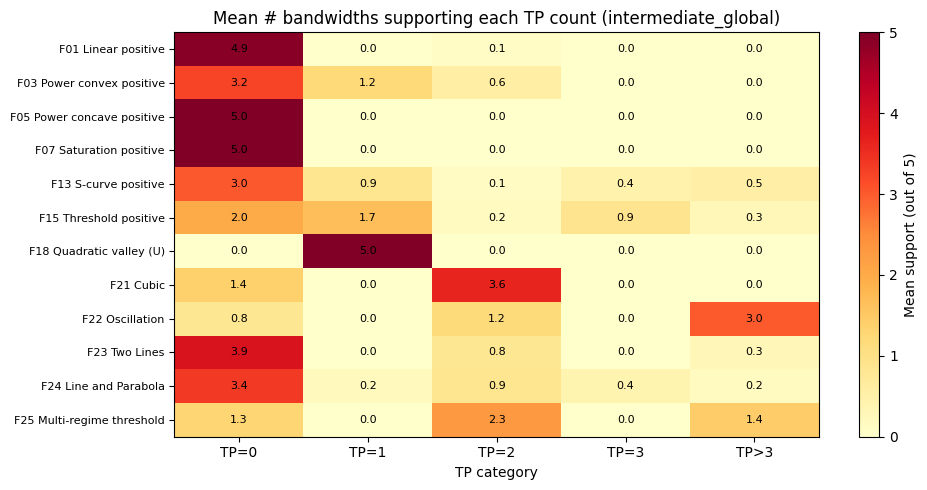

In [41]:
# ── TP support diagnostic tables ──
import matplotlib.pyplot as plt

# ── Table A: Per-family mean TP count at each bandwidth ──
print('=== Per-bandwidth mean TP count by family ===')
if len(sizer_bw_df) > 0:
    _bw_tp = sizer_bw_df.pivot_table(
        index='family_id', columns='bw_index', values='tp_count', aggfunc='mean'
    ).round(2)
    _bw_tp.columns = [f'bw_{int(c)}' for c in _bw_tp.columns]
    _bw_tp.insert(0, 'family_name', _bw_tp.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
    display(_bw_tp)

# ── Tables B: Support distribution for each TP category ──
TP_CATEGORIES = [
    ('n_0tp_bw', 'TP = 0', 'Monotonic (S/Threshold/Saturation…)'),
    ('n_1tp_bw', 'TP = 1', 'U-shape / Spike (F18/F19/F20)'),
    ('n_2tp_bw', 'TP = 2', 'Cubic (F21)'),
    ('n_3tp_bw', 'TP = 3', 'Oscillation / Multi-regime'),
    ('n_gt3tp_bw', 'TP > 3', 'High-frequency oscillation'),
]

for col, tp_label, description in TP_CATEGORIES:
    print(f'\n=== {tp_label} support distribution — {description} ===')
    _support = sizer_df.copy()
    _support[col] = _support[col].fillna(0).astype(int)
    
    _sup_table = _support.groupby('family_id')[col].value_counts().unstack(fill_value=0)
    _sup_table = _sup_table.reindex(columns=range(6), fill_value=0)
    _sup_totals = _sup_table.sum(axis=1)
    _sup_out = pd.DataFrame(index=_sup_table.index)
    _sup_out['family_name'] = _sup_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    _sup_out['n'] = _sup_totals
    for c in _sup_table.columns:
        _sup_out[f'{c}/5'] = [count_percent(int(n), int(t)) for n, t in zip(_sup_table[c], _sup_totals)]
    display(_sup_out)

# ── Plot: dominant TP heatmap ──
fig, ax = plt.subplots(figsize=(10, 5))
tp_cols = ['n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']
tp_labels = ['TP=0', 'TP=1', 'TP=2', 'TP=3', 'TP>3']
_heat = sizer_df.groupby('family_id')[tp_cols].mean()
_heat.columns = tp_labels
_heat = _heat.loc[sorted(_heat.index)]

im = ax.imshow(_heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(tp_labels)))
ax.set_xticklabels(tp_labels)
ax.set_yticks(range(len(_heat.index)))
fnames = [f'{fid} {FAMILY_CATALOGUE.get(fid, {}).get("name", "")}' for fid in _heat.index]
ax.set_yticklabels(fnames, fontsize=8)
for i in range(len(_heat.index)):
    for j in range(len(tp_labels)):
        ax.text(j, i, f'{_heat.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
ax.set_title(f'Mean # bandwidths supporting each TP count ({MIC_ANALYSIS_GATE})')
ax.set_xlabel('TP category')
fig.colorbar(im, ax=ax, label='Mean support (out of 5)')
plt.tight_layout()

In [42]:
# ── Classification based on dominant TP support ──
TP_SUPPORT_MIN = 3  # at least 3/5 bandwidths must agree

def tp_classify(row):
    supports = {
        0: row['n_0tp_bw'],
        1: row['n_1tp_bw'],
        2: row['n_2tp_bw'],
        'ge3': row['n_3tp_bw'] + row['n_gt3tp_bw'],
    }
    dominant = max(supports, key=supports.get)
    dominant_n = supports[dominant]
    
    if dominant_n < TP_SUPPORT_MIN:
        return 'Uncertain'
    
    if dominant == 0:
        return 'TP=0'
    elif dominant == 1:
        return 'TP=1'
    elif dominant == 2:
        return 'TP=2'
    else:
        return 'TP≥3'

sizer_df['sizer_label'] = sizer_df.apply(tp_classify, axis=1)

# ── Expected TP label from catalogue ──
EXPECTED_TP_LABEL = {}
for fid, props in FAMILY_CATALOGUE.items():
    tp = props.get('tp', 'N/A')
    mono = props.get('monotonicity', '')
    if tp == 0 and mono == 'monotonic':
        EXPECTED_TP_LABEL[fid] = 'TP=0'
    elif tp == 1:
        EXPECTED_TP_LABEL[fid] = 'TP=1'
    elif tp == 2:
        EXPECTED_TP_LABEL[fid] = 'TP=2'
    elif tp == 'multiple' or (isinstance(tp, int) and tp > 2):
        EXPECTED_TP_LABEL[fid] = 'TP≥3'
    else:
        EXPECTED_TP_LABEL[fid] = None

# ── Classification table ──
print(f'=== Multiscale TP classification (dominant TP with ≥{TP_SUPPORT_MIN}/5 support) ===')
print(f'Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <{TP_SUPPORT_MIN}/5→Uncertain\n')

_sc = sizer_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
_sc['total'] = _sc.sum(axis=1)

# Column order: TP=0, TP=1, TP=2, TP≥3, Uncertain
_col_order = ['TP=0', 'TP=1', 'TP=2', 'TP≥3', 'Uncertain']
_display_cols = [c for c in _col_order if c in _sc.columns]

_sc_out = pd.DataFrame(index=_sc.index)
_sc_out['family_name'] = _sc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_sc_out['Expected'] = _sc_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
_sc_out['Total'] = [count_percent(n, n) for n in _sc['total']]
for col in _display_cols:
    _sc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sc[col], _sc['total'])]

# Accuracy per family
accuracy = []
for fid in _sc_out.index:
    exp = EXPECTED_TP_LABEL.get(fid)
    total = int(_sc.loc[fid, 'total'])
    if exp is None:
        accuracy.append('N/A')
    elif exp in _sc.columns:
        n_correct = int(_sc.loc[fid, exp])
        accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
    else:
        accuracy.append(f'0/{total} (0.0%)')
_sc_out['Accuracy'] = accuracy
display(_sc_out)

# Overall accuracy (all families with expected label)
_all = sizer_df.copy()
_all['_expected'] = _all['family_id'].map(EXPECTED_TP_LABEL)
_eval = _all[_all['_expected'].notna()].copy()
if len(_eval) > 0:
    _eval['_correct'] = _eval['sizer_label'] == _eval['_expected']
    n_t = len(_eval)
    n_c = int(_eval['_correct'].sum())

=== Multiscale TP classification (dominant TP with ≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,155 (100.0%),155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,TP=0,78 (100.0%),58 (74.4%),16 (20.5%),0 (0.0%),0 (0.0%),4 (5.1%),58/78 (74.4%)
F05,Power concave positive,TP=0,77 (100.0%),77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,TP=0,582 (100.0%),582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582/582 (100.0%)
F13,S-curve positive,TP=0,114 (100.0%),84 (73.7%),0 (0.0%),0 (0.0%),0 (0.0%),30 (26.3%),84/114 (73.7%)
F15,Threshold positive,TP=0,99 (100.0%),25 (25.3%),28 (28.3%),0 (0.0%),9 (9.1%),37 (37.4%),25/99 (25.3%)
F18,Quadratic valley (U),TP=1,173 (100.0%),0 (0.0%),173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),173/173 (100.0%)
F21,Cubic,TP=2,332 (100.0%),0 (0.0%),0 (0.0%),332 (100.0%),0 (0.0%),0 (0.0%),332/332 (100.0%)
F22,Oscillation,TP≥3,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),153/153 (100.0%)


## Method B — KL / QR / HD (distributional tests)

From: *"Thresholds for ecological responses to global change do not emerge from empirical data"*

- **KL**: Does the overall distribution of Y change with X? (permutation test on Y)
- **QR**: Does the spread of the Y distribution change substantially with X? (permutation test on X)
- **HD**: Does Y have multiple modes / two distinct states? (Hartigan's dip test)

Decision rule:
- KL+, QR+, HD+ → Threshold
- KL+, QR+, HD− → Cubic
- otherwise → S-shaped

In [43]:
# ── KL / QR / HD implementation ──
from scipy.stats import ks_2samp
from diptest import diptest as diptest_func

def kl_test(x, y, n_bins=5, n_perm=199, alpha=0.05):
    """KL divergence test: does P(Y|X) differ from P(Y)?
    
    Bins X into quantile bins, computes KL(P(Y|X_bin) || P(Y)) for each bin,
    averages across bins. Permutation test shuffles Y to get null distribution.
    """
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    n = len(x)
    if n < 20:
        return np.nan, np.nan
    
    x_edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    x_edges[0] -= 1e-10
    x_bin_idx = np.digitize(x, x_edges[1:-1])
    
    y_edges = np.linspace(y.min() - 1e-10, y.max() + 1e-10, 21)
    
    p_y_marginal, _ = np.histogram(y, bins=y_edges)
    p_y_marginal = (p_y_marginal + 1) / (p_y_marginal + 1).sum()
    
    def avg_kl(y_vals):
        total_kl = 0
        n_valid = 0
        for b in range(n_bins):
            mask = x_bin_idx == b
            if mask.sum() < 5:
                continue
            p_cond, _ = np.histogram(y_vals[mask], bins=y_edges)
            p_cond = (p_cond + 1) / (p_cond + 1).sum()
            total_kl += np.sum(p_cond * np.log(p_cond / p_y_marginal))
            n_valid += 1
        return total_kl / max(n_valid, 1)
    
    obs_stat = avg_kl(y)
    
    count = 0
    for _ in range(n_perm):
        perm_stat = avg_kl(np.random.permutation(y))
        if perm_stat >= obs_stat:
            count += 1
    
    return obs_stat, (count + 1) / (n_perm + 1)


def qr_test(x, y, n_bins=5, n_perm=199, alpha=0.05):
    """Quantile range test: does the spread of Y change with X?
    
    Bins X, computes 5th-95th percentile width of Y in each bin.
    Test stat = max_spread / min_spread across bins.
    Permutation test shuffles Y.
    """
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    n = len(x)
    if n < 20:
        return np.nan, np.nan
    
    x_edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    x_edges[0] -= 1e-10
    x_bin_idx = np.digitize(x, x_edges[1:-1])
    
    def spread_ratio(y_vals):
        spreads = []
        for b in range(n_bins):
            mask = x_bin_idx == b
            if mask.sum() < 5:
                continue
            yb = y_vals[mask]
            spreads.append(np.percentile(yb, 95) - np.percentile(yb, 5))
        if len(spreads) < 2 or min(spreads) < 1e-10:
            return 0.0
        return max(spreads) / min(spreads)
    
    obs_stat = spread_ratio(y)
    
    count = 0
    for _ in range(n_perm):
        perm_stat = spread_ratio(np.random.permutation(y))
        if perm_stat >= obs_stat:
            count += 1
    
    return obs_stat, (count + 1) / (n_perm + 1)


def hd_test(y, alpha=0.05):
    """Hartigan's dip test for multimodality using diptest package."""
    valid = np.isfinite(y)
    y = y[valid]
    if len(y) < 20:
        return np.nan, np.nan
    dip, pval = diptest_func(y)
    return dip, pval

print('KL / QR / HD helpers defined (diptest package for HD).')

KL / QR / HD helpers defined (diptest package for HD).


In [44]:
# ── Run KL / QR / HD on Complex-path cases ──
np.random.seed(42)

klqrhd_results = []
t0 = time.time()

for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc='KL/QR/HD'):
    pi = int(row['_pt_idx'])
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    
    kl_stat, kl_p = kl_test(x, y)
    qr_stat, qr_p = qr_test(x, y)
    hd_stat, hd_p = hd_test(y)
    
    klqrhd_results.append({
        'case_id': row['case_id'],
        'family_id': row['family_id'],
        'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
        'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
        'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
    })

print(f'KL/QR/HD: {len(klqrhd_results):,} cases in {time.time()-t0:.1f}s')

klqrhd_df = pd.DataFrame(klqrhd_results)
klqrhd_df['family_name'] = klqrhd_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))

# Significance rates per family
print('\n=== Significance rates per family ===')
_sig = klqrhd_df.groupby(['family_id', 'family_name']).agg(
    n=('case_id', 'size'),
    KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
    QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
    HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
)
display(_sig)

KL/QR/HD: 100%|██████████| 2411/2411 [03:29<00:00, 11.53it/s]

KL/QR/HD: 2,411 cases in 209.2s

=== Significance rates per family ===


,,n,KL_sig,QR_sig,HD_sig
family_id,family_name,,,,
F01,Linear positive,155,155 (100.0%),28 (18.1%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),78 (100.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),74 (96.1%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),582 (100.0%),0 (0.0%)
F13,S-curve positive,114,114 (100.0%),83 (72.8%),1 (0.9%)
F15,Threshold positive,99,99 (100.0%),91 (91.9%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),164 (94.8%),0 (0.0%)
F21,Cubic,332,332 (100.0%),332 (100.0%),0 (0.0%)
F22,Oscillation,153,79 (51.6%),4 (2.6%),10 (6.5%)


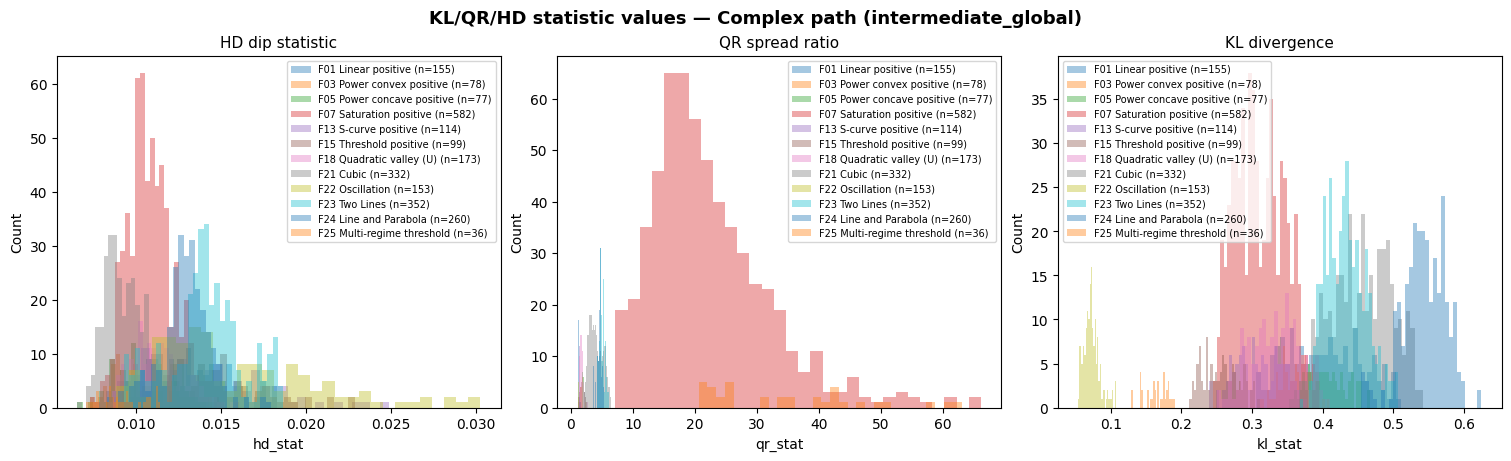


=== HD dip statistic per family (key for S vs Threshold) ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,0.0129,0.0025,0.0082,0.0098,0.0110,0.0128,0.0147,0.0163,0.0183
F03,Power convex positive,78.0,0.0099,0.0016,0.0073,0.0082,0.0088,0.0097,0.0105,0.0120,0.0150
F05,Power concave positive,77.0,0.0104,0.0018,0.0066,0.0085,0.0092,0.0100,0.0115,0.0131,0.0160
F07,Saturation positive,582.0,0.0108,0.0013,0.0073,0.0092,0.0100,0.0107,0.0116,0.0126,0.0161
F13,S-curve positive,114.0,0.0142,0.0033,0.0087,0.0105,0.0114,0.0138,0.0163,0.0184,0.0249
F15,Threshold positive,99.0,0.0147,0.0027,0.0103,0.0118,0.0125,0.0142,0.0161,0.0182,0.0229
F18,Quadratic valley (U),173.0,0.0114,0.0016,0.0084,0.0094,0.0102,0.0113,0.0123,0.0136,0.0160
F21,Cubic,332.0,0.0096,0.0014,0.0066,0.0081,0.0085,0.0093,0.0105,0.0114,0.0145
F22,Oscillation,153.0,0.0159,0.0047,0.0088,0.0112,0.0123,0.0144,0.0189,0.0222,0.0303



=== QR spread ratio per family ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,1.2208,0.0944,1.0724,1.0902,1.1508,1.2171,1.2735,1.3490,1.4980
F03,Power convex positive,78.0,1.7735,0.2119,1.4339,1.5429,1.5974,1.7684,1.8751,1.9701,2.4623
F05,Power concave positive,77.0,1.9795,0.2598,1.3243,1.5769,1.8805,1.9842,2.1351,2.2945,2.5410
F07,Saturation positive,582.0,22.3679,9.6218,7.1672,12.3726,15.6960,20.3580,27.2068,34.4393,66.1162
F13,S-curve positive,114.0,1.3557,0.1204,1.0782,1.1955,1.3036,1.3657,1.4411,1.4913,1.6035
F15,Threshold positive,99.0,1.5835,0.1509,1.2092,1.3771,1.4760,1.5999,1.6980,1.7634,1.8510
F18,Quadratic valley (U),173.0,1.7371,0.3177,1.2495,1.3663,1.5003,1.6910,1.8877,2.2012,2.7179
F21,Cubic,332.0,4.0419,1.0479,2.1488,2.7615,3.1622,3.8955,4.8802,5.5733,6.4360
F22,Oscillation,153.0,1.1849,0.0485,1.0904,1.1270,1.1498,1.1767,1.2182,1.2526,1.3036


In [45]:
# ── KL/QR/HD statistic VALUE distributions (not just significance) ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

stat_cols = [
    ('hd_stat', 'HD dip statistic'),
    ('qr_stat', 'QR spread ratio'),
    ('kl_stat', 'KL divergence'),
]

for ax, (col, title) in zip(axes, stat_cols):
    for fid in sorted(klqrhd_df['family_id'].unique()):
        vals = klqrhd_df.loc[klqrhd_df['family_id'] == fid, col].dropna()
        if len(vals) == 0:
            continue
        fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
        ax.hist(vals, bins=30, alpha=0.4, label=f'{fid} {fname} (n={len(vals)})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

fig.suptitle(f'KL/QR/HD statistic values — Complex path ({MIC_ANALYSIS_GATE})', fontsize=13, fontweight='bold')
plt.show()

# ── Summary table: stat value percentiles per family ──
print('\n=== HD dip statistic per family (key for S vs Threshold) ===')
_hd_summary = klqrhd_df.groupby('family_id')['hd_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
_hd_summary.insert(0, 'family_name', _hd_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
display(_hd_summary)

print('\n=== QR spread ratio per family ===')
_qr_summary = klqrhd_df.groupby('family_id')['qr_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
_qr_summary.insert(0, 'family_name', _qr_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
display(_qr_summary)

In [46]:
# ── KL/QR/HD classification ──
# Step 1: HD significance → Cubic vs S/Threshold
#   HD- (not significant) → Cubic
#   HD+ (significant)     → S/Threshold candidate
# Step 2: Among S/Threshold, use HD dip value to separate
#   Higher dip → Threshold (Y is more clearly bimodal: two distinct states)
#   Lower dip  → S-curve (Y transitions gradually, less bimodal)

HD_DIP_THRESHOLD = 0.02  # tune based on distribution above

def klqrhd_classify(row):
    if any(np.isnan([row.get('kl_sig', np.nan), row.get('qr_sig', np.nan), row.get('hd_sig', np.nan)])):
        return 'failed'
    
    # Step 1: Cubic detection via HD
    if row['kl_sig'] and row['qr_sig'] and not row['hd_sig']:
        return 'Cubic'
    
    # Step 2: S vs Threshold via HD dip value
    hd_val = row.get('hd_stat', np.nan)
    if np.isnan(hd_val):
        return 'S/Threshold'
    
    if hd_val >= HD_DIP_THRESHOLD:
        return 'Threshold'
    else:
        return 'S-curve'

klqrhd_df['klqrhd_label'] = klqrhd_df.apply(klqrhd_classify, axis=1)

# ── Classification table ──
print(f'=== KL/QR/HD classification (HD_DIP_THRESHOLD={HD_DIP_THRESHOLD}) ===')
print(f'Rule: HD- → Cubic | HD+ & dip≥{HD_DIP_THRESHOLD} → Threshold | HD+ & dip<{HD_DIP_THRESHOLD} → S-curve\n')

_kc = klqrhd_df.groupby(['family_id', 'klqrhd_label']).size().unstack(fill_value=0)
_kc['total'] = _kc.sum(axis=1)
_kc_out = pd.DataFrame(index=_kc.index)
_kc_out['family_name'] = _kc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_kc_out['Total'] = [count_percent(n, n) for n in _kc['total']]
for col in sorted(_kc.columns.drop('total')):
    _kc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_kc[col], _kc['total'])]

# Expected labels
EXPECTED_KLQRHD = {}
for fid, props in FAMILY_CATALOGUE.items():
    shape = props.get('special_shape', '')
    if 'S-curve' in shape:
        EXPECTED_KLQRHD[fid] = 'S-curve'
    elif 'threshold' in shape.lower() and 'windowed' not in shape.lower():
        EXPECTED_KLQRHD[fid] = 'Threshold'
    elif 'cubic' in shape:
        EXPECTED_KLQRHD[fid] = 'Cubic'
    else:
        EXPECTED_KLQRHD[fid] = None

_kc_out['Expected'] = _kc_out.index.map(lambda f: EXPECTED_KLQRHD.get(f, 'N/A'))
accuracy = []
for fid in _kc_out.index:
    exp = EXPECTED_KLQRHD.get(fid)
    total = int(_kc.loc[fid, 'total'])
    if exp is None or exp not in _kc.columns:
        accuracy.append('N/A')
    else:
        n_correct = int(_kc.loc[fid, exp])
        accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
_kc_out['Accuracy'] = accuracy
display(_kc_out)

# F13/F15/F21 summary
_target = klqrhd_df[klqrhd_df['family_id'].isin(['F13', 'F15', 'F21'])].copy()
if len(_target) > 0:
    _target['_expected'] = _target['family_id'].map(EXPECTED_KLQRHD)
    _target['_correct'] = _target['klqrhd_label'] == _target['_expected']
    n_t = len(_target)
    n_c = int(_target['_correct'].sum())
    print(f'\nF13/F15/F21 accuracy: {n_c}/{n_t} ({n_c/n_t:.1%})')
    
    # Merged S/Threshold accuracy
    _target['_label_merged'] = _target['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
    _target['_expected_merged'] = _target['_expected'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
    n_cm = int((_target['_label_merged'] == _target['_expected_merged']).sum())
    print(f'F13/F15/F21 accuracy (S/T merged): {n_cm}/{n_t} ({n_cm/n_t:.1%})')

=== KL/QR/HD classification (HD_DIP_THRESHOLD=0.02) ===
Rule: HD- → Cubic | HD+ & dip≥0.02 → Threshold | HD+ & dip<0.02 → S-curve



,family_name,Total,Cubic,S-curve,Threshold,Expected,Accuracy
family_id,,,,,,,
F01,Linear positive,155 (100.0%),28 (18.1%),127 (81.9%),0 (0.0%),None,N/A
F03,Power convex positive,78 (100.0%),78 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F05,Power concave positive,77 (100.0%),74 (96.1%),3 (3.9%),0 (0.0%),None,N/A
F07,Saturation positive,582 (100.0%),582 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F13,S-curve positive,114 (100.0%),82 (71.9%),31 (27.2%),1 (0.9%),S-curve,31/114 (27.2%)
F15,Threshold positive,99 (100.0%),91 (91.9%),8 (8.1%),0 (0.0%),Threshold,0/99 (0.0%)
F18,Quadratic valley (U),173 (100.0%),164 (94.8%),9 (5.2%),0 (0.0%),None,N/A
F21,Cubic,332 (100.0%),332 (100.0%),0 (0.0%),0 (0.0%),Cubic,332/332 (100.0%)
F22,Oscillation,153 (100.0%),2 (1.3%),124 (81.0%),27 (17.6%),None,N/A



F13/F15/F21 accuracy: 363/545 (66.6%)
F13/F15/F21 accuracy (S/T merged): 372/545 (68.3%)


## S-curve vs Threshold separation

Within non-Cubic cases (SiZer S/Threshold), use KL/QR/HD **statistic values** (not significance) to separate:
- **HD dip value**: Threshold has more clearly bimodal Y → larger dip
- **QR spread ratio**: Threshold has sharper spread change → larger ratio
- **SiZer width ratio**: S-curve has wider derivative region → larger width ratio

In [47]:
# ── S vs Threshold: statistic value distributions ──
import matplotlib.pyplot as plt

# Merge SiZer + KL/QR/HD results
_st_merge = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
    klqrhd_df[['case_id', 'hd_stat', 'qr_stat', 'hd_sig', 'qr_sig']], on='case_id', how='inner'
)

# Focus on S/Threshold cases (non-Cubic by SiZer) that are F13 or F15
_st_focus = _st_merge[
    (_st_merge['family_id'].isin(['F13', 'F15'])) &
    (_st_merge['sizer_label'] == 'S/Threshold')
].copy()

print(f'S/Threshold cases for F13/F15: {len(_st_focus)}')
print(f'  F13 S-curve: {(_st_focus["family_id"]=="F13").sum()}')
print(f'  F15 Threshold: {(_st_focus["family_id"]=="F15").sum()}')

if len(_st_focus) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    
    indicators = [
        ('hd_stat', 'HD dip statistic', 'Threshold should be higher (bimodal Y)'),
        ('qr_stat', 'QR spread ratio', 'Threshold should be higher (sharp spread change)'),
    ]
    
    for ax, (col, title, note) in zip(axes, indicators):
        for fid, color, label in [('F13', 'steelblue', 'F13 S-curve'), ('F15', 'coral', 'F15 Threshold')]:
            vals = _st_focus.loc[_st_focus['family_id'] == fid, col].dropna()
            ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{label} (n={len(vals)})')
        ax.set_title(f'{title}\n({note})', fontsize=9)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
    
    fig.suptitle(f'S-curve vs Threshold statistic distributions ({MIC_ANALYSIS_GATE})', fontsize=12)
    plt.show()
    
    # Summary table
    print('\n=== Statistic value summary: F13 vs F15 ===')
    _summary = _st_focus.groupby('family_id').agg(
        n=('case_id', 'size'),
        hd_dip_median=('hd_stat', 'median'),
        hd_dip_mean=('hd_stat', 'mean'),
        qr_ratio_median=('qr_stat', 'median'),
        qr_ratio_mean=('qr_stat', 'mean'),
    ).round(4)
    _summary.insert(0, 'family_name', _summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
    display(_summary)
else:
    print('No S/Threshold cases for F13/F15.')

S/Threshold cases for F13/F15: 0
  F13 S-curve: 0
  F15 Threshold: 0
No S/Threshold cases for F13/F15.


In [48]:
# ── S vs Threshold classification attempt ──
# Try different indicators to separate F13 S-curve from F15 Threshold

if len(_st_focus) > 0:
    results = []
    
    for col, name, direction in [
        ('hd_stat', 'HD dip', 'high_is_threshold'),
        ('qr_stat', 'QR ratio', 'high_is_threshold'),
    ]:
        vals = _st_focus[col].dropna()
        if len(vals) == 0:
            continue
        
        # Sweep thresholds, find best accuracy
        thresholds = np.percentile(vals, np.arange(10, 91, 5))
        best_thr_acc = 0
        best_thr = 0
        
        for thr in thresholds:
            if direction == 'high_is_threshold':
                pred = np.where(_st_focus[col] >= thr, 'Threshold', 'S-curve')
            else:
                pred = np.where(_st_focus[col] >= thr, 'S-curve', 'Threshold')
            
            truth = _st_focus['family_id'].map({'F13': 'S-curve', 'F15': 'Threshold'})
            acc = (pred == truth).mean()
            if acc > best_thr_acc:
                best_thr_acc = acc
                best_thr = thr
        
        results.append({
            'Indicator': name,
            'Best threshold': f'{best_thr:.4f}',
            'Accuracy': f'{best_thr_acc:.1%}',
            'Direction': direction,
        })
    
    print('=== S vs Threshold: best single-indicator classification ===')
    display(pd.DataFrame(results))
else:
    print('No data to evaluate.')

No data to evaluate.


## Head-to-head comparison

Merge SiZer and KL/QR/HD results and compare accuracy per family.

In [49]:
# ── Comparison: Multiscale TP vs KL/QR/HD ──
compare = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
    klqrhd_df[['case_id', 'klqrhd_label', 'hd_stat', 'qr_stat']], on='case_id', how='outer'
)

compare['expected_tp'] = compare['family_id'].map(EXPECTED_TP_LABEL)
compare['tp_correct'] = compare['sizer_label'] == compare['expected_tp']

compare['expected_klqrhd'] = compare['family_id'].map(EXPECTED_KLQRHD)
compare['klqrhd_correct'] = compare['klqrhd_label'] == compare['expected_klqrhd']
compare['klqrhd_merged'] = compare['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
compare['expected_merged'] = compare['expected_klqrhd'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
compare['klqrhd_correct_merged'] = compare['klqrhd_merged'] == compare['expected_merged']

rows = []
for fid in sorted(compare['family_id'].unique()):
    sub = compare[compare['family_id'] == fid]
    fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
    n = len(sub)
    exp_tp = EXPECTED_TP_LABEL.get(fid)
    
    if exp_tp is not None:
        tc = int(sub['tp_correct'].sum())
        tp_acc = f'{tc}/{n} ({tc/n:.1%})'
    else:
        tp_acc = 'N/A'
    
    exp_kl = EXPECTED_KLQRHD.get(fid)
    if exp_kl is not None:
        kc = int(sub['klqrhd_correct'].sum())
        kcm = int(sub['klqrhd_correct_merged'].sum())
        kl_acc = f'{kc}/{n} ({kc/n:.1%})'
        kl_acc_m = f'{kcm}/{n} ({kcm/n:.1%})'
    else:
        kl_acc = 'N/A'
        kl_acc_m = 'N/A'
    
    rows.append({
        'Family': f'{fid} {fname}',
        'n': n,
        'Expected (TP)': exp_tp or 'N/A',
        'Multiscale TP': tp_acc,
        'KL/QR/HD (3-way)': kl_acc,
        'KL/QR/HD (S/T merged)': kl_acc_m,
    })

# Overall for families with expected TP label
_eval = compare[compare['expected_tp'].notna()]
if len(_eval) > 0:
    n_t = len(_eval)
    tc_t = int(_eval['tp_correct'].sum())
    rows.append({
        'Family': 'Overall (with expected)',
        'n': n_t,
        'Expected (TP)': '',
        'Multiscale TP': f'{tc_t}/{n_t} ({tc_t/n_t:.1%})',
        'KL/QR/HD (3-way)': 'N/A',
        'KL/QR/HD (S/T merged)': 'N/A',
    })

print('=== Comparison: Multiscale TP vs KL/QR/HD ===')

=== Comparison: Multiscale TP vs KL/QR/HD ===
